# Visit with Us: Wellness Tourism Package Prediction
### Advanced Machine Learning and MLOps — Project 10

**Business context.** "Visit with Us" is introducing a new Wellness Tourism
Package and wants to identify, before the sales team ever makes a call,
which existing customers are most likely to buy it. This notebook builds
that predictive model and the MLOps pipeline that trains, tunes, evaluates,
deploys and continuously updates it.

**Objective.** Design and document an end-to-end MLOps pipeline — data
registration, data preparation, model building with experiment tracking,
model deployment on Streamlit, and automation through a GitHub Actions
workflow — that predicts `ProdTaken` (1 = customer purchases the Wellness
Package, 0 = does not).

**Repository layout used throughout this notebook**

```
visit-with-us-mlops/
├── data/
│   ├── tourism.csv
│   └── processed/            (created by the data preparation step)
├── src/
│   ├── data_register.py
│   ├── data_prep.py
│   └── train.py
├── model/
│   ├── best_model.joblib
│   └── best_model_metadata.json
├── app/
│   ├── streamlit_app.py
│   └── requirements.txt
├── .github/workflows/
│   └── pipeline.yml
└── requirements.txt
```

Every file referenced below is written to disk from this notebook with
`%%writefile`, so running the notebook top to bottom reproduces the exact
repository that is pushed to GitHub.

Install the packages this notebook needs. `pandas`, `scikit-learn` and
`matplotlib` normally ship with Colab/Jupyter already, but `mlflow` does
not, and `xgboost`'s pre-installed version can be outdated — this cell
makes the environment self-contained regardless of what platform runs
it.

In [1]:
import subprocess
import sys


def pip_install(packages):
    cmd = [sys.executable, "-m", "pip", "install", "-q"] + packages
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0 and "externally-managed-environment" in result.stderr:
        # Debian/Ubuntu-managed Python (PEP 668) - safe to override in an
        # isolated notebook/container environment such as this one.
        result = subprocess.run(cmd + ["--break-system-packages"], capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError(f"Failed to install: {packages}")


pip_install(["mlflow", "xgboost", "joblib", "scikit-learn", "pandas", "matplotlib", "seaborn"])
print("Required packages are installed.")

Required packages are installed.


In [2]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path(".").resolve()
print("Working directory:", PROJECT_ROOT)

Working directory: /home/claude/fresh_test3


## 1. Data Registration

Rubric requirement: create a master folder with a `data/` subfolder holding
the dataset, and register the dataset with a script that validates the
expected columns and prints a summary.

The cell below creates the folder structure and places `tourism.csv`
inside `data/`.

In [3]:
folders = ["data", "data/processed", "src", "model", "app", ".github/workflows"]
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Created project folders:")
for folder in folders:
    print(" -", folder)

Created project folders:
 - data
 - data/processed
 - src
 - model
 - app
 - .github/workflows


**Before running the next cell:** make sure `tourism.csv` has been
uploaded somewhere this notebook can see it — either directly into
`data/tourism.csv`, or just uploaded to the notebook's working directory
(e.g. via Colab's file browser / `Files > Upload`). The cell below finds
it automatically and copies it into `data/tourism.csv` if it isn't there
already, so the rest of the pipeline always reads from one consistent
path.

In [4]:
import shutil

DATA_TARGET = Path("data/tourism.csv")

if not DATA_TARGET.exists():
    candidate_paths = [
        Path("tourism.csv"),
        Path("/content/tourism.csv"),
        Path("/mnt/data/tourism.csv"),
        Path("/mnt/user-data/uploads/tourism.csv"),
    ]
    found = next((p for p in candidate_paths if p.exists()), None)
    if found is not None:
        shutil.copy(found, DATA_TARGET)
        print(f"Copied dataset from {found} to {DATA_TARGET}")
    else:
        raise FileNotFoundError(
            "tourism.csv was not found in data/, the working directory, or /content. "
            "Upload tourism.csv (e.g. via the Colab file browser, or Jupyter's Upload "
            "button) and re-run this cell."
        )
else:
    print(f"Dataset already present at {DATA_TARGET}")

Copied dataset from tourism.csv to data/tourism.csv


Place the raw dataset in `data/tourism.csv` (already done for this run) and write the registration script.

In [5]:
%%writefile src/data_register.py
"""
Data Registration Script
-------------------------
Validates that the raw tourism dataset placed in the data/ folder has the
expected structure before it is allowed to enter the pipeline, and prints
a summary report of the dataset.
"""

import sys
from pathlib import Path

import pandas as pd

DATA_PATH = Path(__file__).resolve().parents[1] / "data" / "tourism.csv"

EXPECTED_COLUMNS = [
    "CustomerID", "ProdTaken", "Age", "TypeofContact", "CityTier",
    "DurationOfPitch", "Occupation", "Gender", "NumberOfPersonVisiting",
    "NumberOfFollowups", "ProductPitched", "PreferredPropertyStar",
    "MaritalStatus", "NumberOfTrips", "Passport", "PitchSatisfactionScore",
    "OwnCar", "NumberOfChildrenVisiting", "Designation", "MonthlyIncome",
]


def register_dataset(path: Path = DATA_PATH) -> pd.DataFrame:
    """Load the dataset and validate its schema, then return it."""
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found at {path}")

    df = pd.read_csv(path)
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    missing_columns = set(EXPECTED_COLUMNS) - set(df.columns)
    if missing_columns:
        raise ValueError(f"Dataset is missing expected columns: {sorted(missing_columns)}")

    print("=" * 60)
    print("DATA REGISTRATION SUMMARY")
    print("=" * 60)
    print(f"Source file            : {path}")
    print(f"Rows                   : {df.shape[0]}")
    print(f"Columns                : {df.shape[1]}")
    print(f"Expected columns found : {len(EXPECTED_COLUMNS)}/{len(EXPECTED_COLUMNS)}")
    print(f"Duplicate rows         : {df.duplicated().sum()}")
    print(f"Duplicate CustomerIDs  : {df['CustomerID'].duplicated().sum()}")
    print(f"Missing values (total) : {int(df.isnull().sum().sum())}")
    print(f"Target column          : ProdTaken")
    print(f"Target distribution    :\n{df['ProdTaken'].value_counts(normalize=True).round(3).to_string()}")
    print("=" * 60)
    print("Dataset registered successfully.")

    return df


if __name__ == "__main__":
    try:
        register_dataset()
    except Exception as exc:
        print(f"Data registration failed: {exc}")
        sys.exit(1)


Writing src/data_register.py


In [6]:
!python src/data_register.py

DATA REGISTRATION SUMMARY
Source file            : /home/claude/fresh_test3/data/tourism.csv
Rows                   : 4128
Columns                : 20
Expected columns found : 20/20
Duplicate rows         : 0
Duplicate CustomerIDs  : 0
Missing values (total) : 0
Target column          : ProdTaken
Target distribution    :
ProdTaken
0    0.807
1    0.193
Dataset registered successfully.


This script is what the `data-registration` job in the GitHub Actions
pipeline runs on every push, so a schema change in the raw data fails the
pipeline immediately rather than silently corrupting downstream steps.

## 2. Exploratory Data Analysis

Before writing the cleaning logic, we look at the raw data to decide what
actually needs fixing: inconsistent category labels, outliers, and the
overall shape of the class imbalance.

In [7]:
df_raw = pd.read_csv("data/tourism.csv")
df_raw = df_raw.loc[:, ~df_raw.columns.str.contains("^Unnamed")]
print(df_raw.shape)
df_raw.head()

(4128, 20)


,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,3.0,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


In [8]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4128 non-null   int64  
 1   ProdTaken                 4128 non-null   int64  
 2   Age                       4128 non-null   float64
 3   TypeofContact             4128 non-null   str    
 4   CityTier                  4128 non-null   int64  
 5   DurationOfPitch           4128 non-null   float64
 6   Occupation                4128 non-null   str    
 7   Gender                    4128 non-null   str    
 8   NumberOfPersonVisiting    4128 non-null   int64  
 9   NumberOfFollowups         4128 non-null   float64
 10  ProductPitched            4128 non-null   str    
 11  PreferredPropertyStar     4128 non-null   float64
 12  MaritalStatus             4128 non-null   str    
 13  NumberOfTrips             4128 non-null   float64
 14  Passport           

In [9]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4128.0,202527.763808,1409.439133,200000.0,201320.75,202603.5,203748.25,204887.0
ProdTaken,4128.0,0.193072,0.394757,0.0,0.00,0.0,0.00,1.0
Age,4128.0,37.231831,9.174521,18.0,31.00,36.0,43.00,61.0
CityTier,4128.0,1.663275,0.920640,1.0,1.00,1.0,3.00,3.0
DurationOfPitch,4128.0,15.584787,8.398142,5.0,9.00,14.0,20.00,127.0
NumberOfPersonVisiting,4128.0,2.949370,0.718818,1.0,2.00,3.0,3.00,5.0
NumberOfFollowups,4128.0,3.741521,1.006786,1.0,3.00,4.0,4.00,6.0
PreferredPropertyStar,4128.0,3.578488,0.795031,3.0,3.00,3.0,4.00,5.0
NumberOfTrips,4128.0,3.295300,1.856300,1.0,2.00,3.0,4.00,22.0
Passport,4128.0,0.295300,0.456233,0.0,0.00,0.0,1.00,1.0


In [10]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print()
print("Duplicate rows:", df_raw.duplicated().sum())
print("Duplicate CustomerIDs:", df_raw['CustomerID'].duplicated().sum())

Missing values per column:
CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

Duplicate rows: 0
Duplicate CustomerIDs: 0


In [11]:
categorical_cols = df_raw.select_dtypes(include="object").columns.tolist()
for col in categorical_cols:
    print(f"{col}: {sorted(df_raw[col].unique())}")

TypeofContact: ['Company Invited', 'Self Enquiry']
Occupation: ['Free Lancer', 'Large Business', 'Salaried', 'Small Business']
Gender: ['Fe Male', 'Female', 'Male']
ProductPitched: ['Basic', 'Deluxe', 'King', 'Standard', 'Super Deluxe']
MaritalStatus: ['Divorced', 'Married', 'Single', 'Unmarried']
Designation: ['AVP', 'Executive', 'Manager', 'Senior Manager', 'VP']


Two label inconsistencies stand out and need cleaning before modeling:

- `Gender` contains both `Female` and the misspelled `Fe Male` for the same category.
- `MaritalStatus` contains both `Single` and `Unmarried`, which describe the same status.

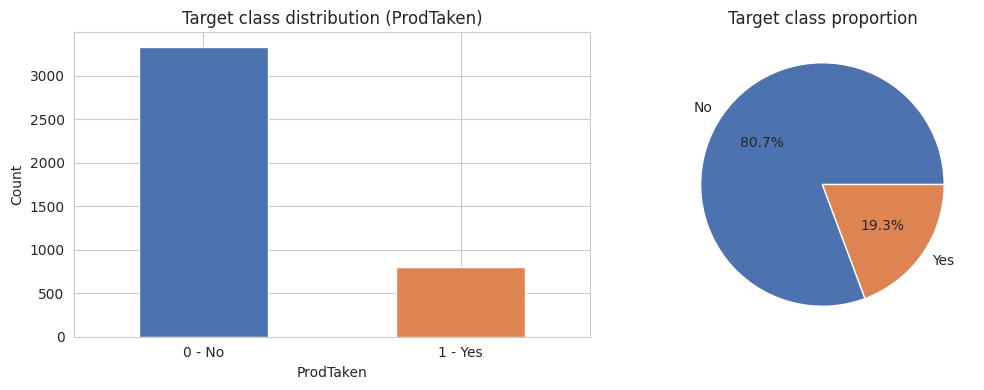

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

df_raw["ProdTaken"].value_counts().plot(kind="bar", ax=ax[0], color=["#4C72B0", "#DD8452"])
ax[0].set_title("Target class distribution (ProdTaken)")
ax[0].set_xlabel("ProdTaken")
ax[0].set_ylabel("Count")
ax[0].set_xticklabels(["0 - No", "1 - Yes"], rotation=0)

df_raw["ProdTaken"].value_counts(normalize=True).plot(
    kind="pie", ax=ax[1], autopct="%1.1f%%", labels=["No", "Yes"], colors=["#4C72B0", "#DD8452"]
)
ax[1].set_ylabel("")
ax[1].set_title("Target class proportion")

plt.tight_layout()
plt.show()

The target is imbalanced: roughly 81% of customers did not buy the package versus 19% who did. This is factored into model evaluation by favouring F1 / recall over raw accuracy.

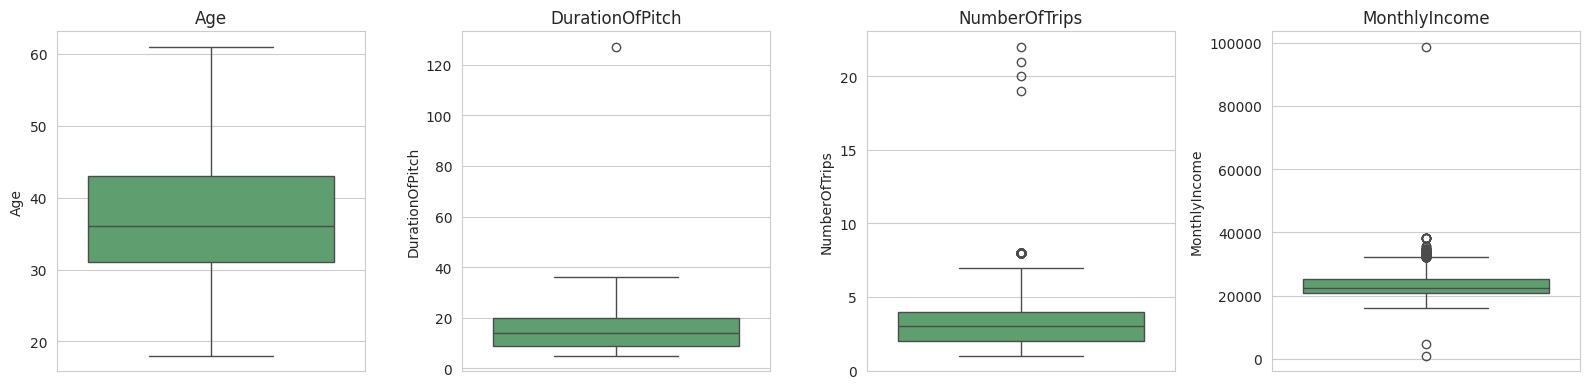

In [13]:
numeric_cols = ["Age", "DurationOfPitch", "NumberOfTrips", "MonthlyIncome"]
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df_raw[col], ax=ax, color="#55A868")
    ax.set_title(col)
plt.tight_layout()
plt.show()

`DurationOfPitch` (max ~127 minutes for a sales pitch) and `NumberOfTrips`
(max 22 trips/year) contain implausible outliers. These are capped at the
99th percentile during cleaning rather than dropped, to avoid losing
customers who are otherwise valid records.

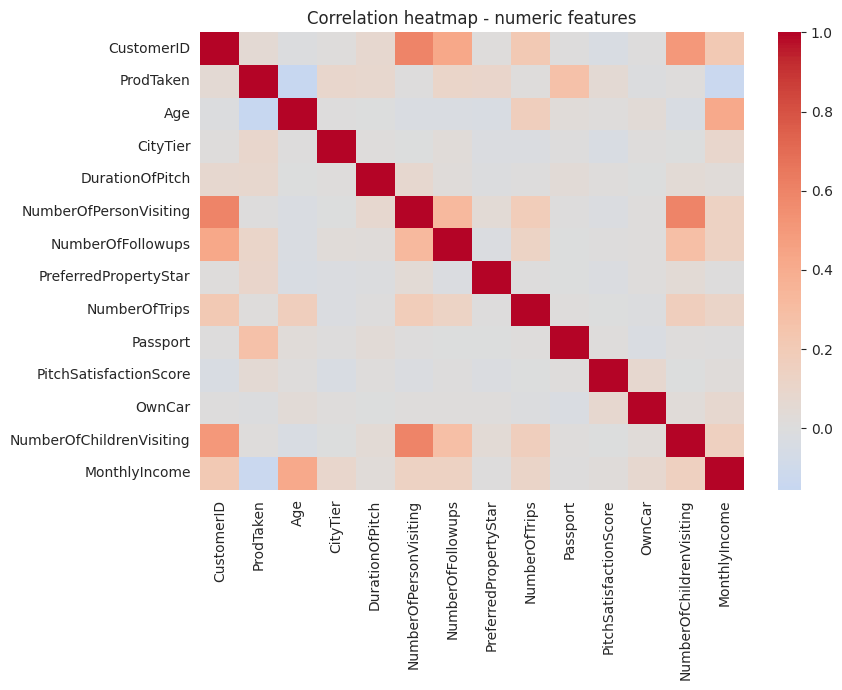

In [14]:
plt.figure(figsize=(9, 7))
corr = df_raw.select_dtypes(include="number").corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation heatmap - numeric features")
plt.tight_layout()
plt.show()

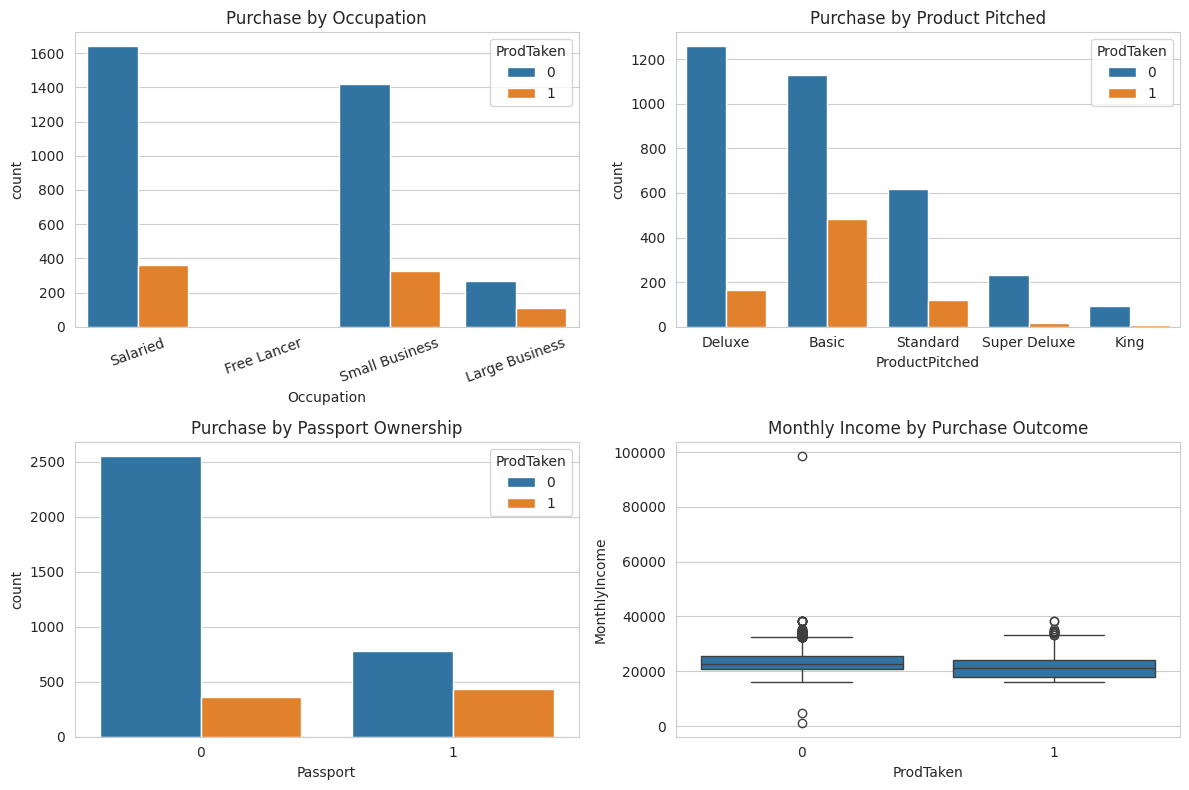

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.countplot(data=df_raw, x="Occupation", hue="ProdTaken", ax=axes[0, 0])
axes[0, 0].set_title("Purchase by Occupation")
axes[0, 0].tick_params(axis="x", rotation=20)

sns.countplot(data=df_raw, x="ProductPitched", hue="ProdTaken", ax=axes[0, 1])
axes[0, 1].set_title("Purchase by Product Pitched")

sns.countplot(data=df_raw, x="Passport", hue="ProdTaken", ax=axes[1, 0])
axes[1, 0].set_title("Purchase by Passport Ownership")

sns.boxplot(data=df_raw, x="ProdTaken", y="MonthlyIncome", ax=axes[1, 1])
axes[1, 1].set_title("Monthly Income by Purchase Outcome")

plt.tight_layout()
plt.show()

Early signal: customers pitched the `Basic` package, holders of a
passport, and free lancers / small-business owners show a visibly higher
purchase rate. These patterns are revisited in the feature-importance
analysis after modeling.

## 3. Data Preparation

Rubric requirement: load the dataset from the repository `data/` folder,
clean it, remove unnecessary columns, split into train/test, save the
splits locally, and make them available to the next pipeline job as a
workflow artifact (`actions/upload-artifact` in `pipeline.yml`, Section 5).

In [16]:
%%writefile src/data_prep.py
"""
Data Preparation Script
------------------------
Loads the raw dataset from the repository data/ folder, cleans it,
engineers the feature set, splits it into train and test sets, and
saves both splits locally so they can be picked up as a workflow
artifact by the next job in the pipeline.
"""

from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split

ROOT = Path(__file__).resolve().parents[1]
RAW_PATH = ROOT / "data" / "tourism.csv"
PROCESSED_DIR = ROOT / "data" / "processed"

TARGET = "ProdTaken"
ID_COLUMNS = ["CustomerID", "Unnamed: 0"]


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.drop(columns=[c for c in ID_COLUMNS if c in df.columns], errors="ignore")
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    if "Gender" in df.columns:
        df["Gender"] = df["Gender"].replace({"Fe Male": "Female"})
    if "MaritalStatus" in df.columns:
        df["MaritalStatus"] = df["MaritalStatus"].replace({"Unmarried": "Single"})

    if "DurationOfPitch" in df.columns:
        df["DurationOfPitch"] = df["DurationOfPitch"].clip(upper=df["DurationOfPitch"].quantile(0.99))
    if "NumberOfTrips" in df.columns:
        df["NumberOfTrips"] = df["NumberOfTrips"].clip(upper=df["NumberOfTrips"].quantile(0.99))

    num_cols = df.select_dtypes(include="number").columns.drop(TARGET, errors="ignore")
    cat_cols = df.select_dtypes(exclude="number").columns

    for col in num_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    for col in cat_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])

    df = df.drop_duplicates()
    return df


def prepare_data(raw_path: Path = RAW_PATH, output_dir: Path = PROCESSED_DIR, test_size: float = 0.2, random_state: int = 42):
    df = pd.read_csv(raw_path)
    df = clean_data(df)

    X = df.drop(columns=[TARGET])
    y = df[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    output_dir.mkdir(parents=True, exist_ok=True)
    X_train.to_csv(output_dir / "X_train.csv", index=False)
    X_test.to_csv(output_dir / "X_test.csv", index=False)
    y_train.to_csv(output_dir / "y_train.csv", index=False)
    y_test.to_csv(output_dir / "y_test.csv", index=False)

    print(f"Cleaned dataset shape : {df.shape}")
    print(f"Train shape           : {X_train.shape}")
    print(f"Test shape            : {X_test.shape}")
    print(f"Splits saved to       : {output_dir}")

    return X_train, X_test, y_train, y_test


if __name__ == "__main__":
    prepare_data()


Writing src/data_prep.py


In [17]:
!python src/data_prep.py

Cleaned dataset shape : (4011, 19)
Train shape           : (3208, 18)
Test shape            : (803, 18)
Splits saved to       : /home/claude/fresh_test3/data/processed


In [18]:
import sys
sys.path.insert(0, "src")
from data_prep import clean_data

df_clean = clean_data(df_raw)
print("Gender values after cleaning:", sorted(df_clean["Gender"].unique()))
print("MaritalStatus values after cleaning:", sorted(df_clean["MaritalStatus"].unique()))
df_clean.head()

Gender values after cleaning: ['Female', 'Male']
MaritalStatus values after cleaning: ['Divorced', 'Married', 'Single']


,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,32.0,Company Invited,1,8.0,Salaried,Male,3,3.0,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


In [19]:
X_train = pd.read_csv("data/processed/X_train.csv")
X_test = pd.read_csv("data/processed/X_test.csv")
y_train = pd.read_csv("data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("data/processed/y_test.csv").squeeze("columns")

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test target balance:\n", y_test.value_counts(normalize=True).round(3))

X_train: (3208, 18)  X_test: (803, 18)
Train target balance:
 ProdTaken
0    0.807
1    0.193
Name: proportion, dtype: float64
Test target balance:
 ProdTaken
0    0.807
1    0.193
Name: proportion, dtype: float64


In the GitHub Actions pipeline, these four CSVs are not just saved to
disk — the `data-preparation` job uploads the whole `data/processed/`
folder with `actions/upload-artifact`, and the `model-building` job
downloads it with `actions/download-artifact` before training starts
(see `pipeline.yml`, Section 5). This is what "make the train/test splits
available to the next job as a workflow artifact" means in practice.

## 4. Model Building with Experiment Tracking

Rubric requirement: load the train/test workflow artifact, define models
and hyperparameters, tune with cross-validation, log every run's
parameters and metrics, evaluate performance, and save the best model so
the pipeline can commit it to the repository.

Five tree-based classifiers from the approved list are tried: Decision
Tree, Random Forest, AdaBoost, Gradient Boosting and XGBoost. Each is
wrapped in a `Pipeline` with the same preprocessing so the comparison is
fair, tuned with `GridSearchCV`, and tracked with MLflow.

In [20]:
%%writefile src/train.py
"""
Model Building Script with Experiment Tracking
------------------------------------------------
Loads the train/test split produced by data_prep.py (delivered to this
job as a workflow artifact in the GitHub Actions pipeline), builds a
preprocessing + model pipeline for several candidate algorithms, tunes
each with GridSearchCV, logs every run and its parameters with MLflow,
evaluates on the held-out test set, and commits the best-performing
model to the repository as model/best_model.joblib.
"""

import json
from pathlib import Path

import joblib
import mlflow
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

ROOT = Path(__file__).resolve().parents[1]
PROCESSED_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "model"
MLRUNS_DIR = ROOT / "mlruns"

CANDIDATE_MODELS = {
    "DecisionTree": {
        "estimator": DecisionTreeClassifier(random_state=42),
        "params": {
            "model__max_depth": [4, 6, 8, None],
            "model__min_samples_split": [2, 5, 10],
        },
    },
    "RandomForest": {
        "estimator": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [150, 300],
            "model__max_depth": [8, 12, None],
            "model__min_samples_split": [2, 5],
        },
    },
    "AdaBoost": {
        "estimator": AdaBoostClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1, 1.0],
        },
    },
    "GradientBoosting": {
        "estimator": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [150, 250],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [3, 5],
        },
    },
    "XGBoost": {
        "estimator": XGBClassifier(random_state=42, eval_metric="logloss"),
        "params": {
            "model__n_estimators": [150, 300],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.05, 0.1],
        },
    },
}


def load_splits():
    X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
    X_test = pd.read_csv(PROCESSED_DIR / "X_test.csv")
    y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").squeeze("columns")
    y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze("columns")
    return X_train, X_test, y_train, y_test


def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_features = X.select_dtypes(include="number").columns.tolist()
    cat_features = X.select_dtypes(exclude="number").columns.tolist()
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ]
    )


def evaluate(model, X_test, y_test) -> dict:
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    return {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, proba),
    }


def run_experiments():
    X_train, X_test, y_train, y_test = load_splits()
    preprocessor = build_preprocessor(X_train)

    MLRUNS_DIR.mkdir(parents=True, exist_ok=True)
    mlflow.set_tracking_uri(f"sqlite:///{MLRUNS_DIR / 'mlflow.db'}")
    mlflow.set_experiment("visit-with-us-wellness-package")

    results = []
    best_score = -1
    best_model = None
    best_name = None
    best_metrics = None

    for name, cfg in CANDIDATE_MODELS.items():
        pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", cfg["estimator"])])
        search = GridSearchCV(pipeline, param_grid=cfg["params"], scoring="f1", cv=5, n_jobs=-1)

        with mlflow.start_run(run_name=name):
            search.fit(X_train, y_train)
            metrics = evaluate(search.best_estimator_, X_test, y_test)

            mlflow.log_params(search.best_params_)
            mlflow.log_metrics(metrics)
            mlflow.set_tag("model_family", name)

            results.append({"model": name, "best_params": search.best_params_, **metrics})

            if metrics["f1"] > best_score:
                best_score = metrics["f1"]
                best_model = search.best_estimator_
                best_name = name
                best_metrics = metrics

    results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
    print(results_df.to_string(index=False))

    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(best_model, MODEL_DIR / "best_model.joblib")

    with open(MODEL_DIR / "best_model_metadata.json", "w") as f:
        json.dump({"model_name": best_name, "metrics": best_metrics}, f, indent=2)

    print(f"\nBest model: {best_name}")
    print(f"Metrics   : {best_metrics}")
    print(f"Saved to  : {MODEL_DIR / 'best_model.joblib'}")

    return results_df, best_name, best_metrics


if __name__ == "__main__":
    run_experiments()


Writing src/train.py


Running the script below performs the full tuning sweep (5 algorithms x grid search x 5-fold cross-validation) and logs every run to the local MLflow tracking store at `mlruns/mlflow.db`.

In [21]:
!python src/train.py

2026/09/04 08:09:16 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/04 08:09:16 INFO mlflow.store.db.utils: Updating database tables


2026/09/04 08:09:17 INFO mlflow.tracking.fluent: Experiment with name 'visit-with-us-wellness-package' does not exist. Creating a new experiment.


           model                                                                           best_params  accuracy  precision   recall       f1  roc_auc
         XGBoost      {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 300}  0.941469   0.942623 0.741935 0.830325 0.957786
GradientBoosting      {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 250}  0.926526   0.913793 0.683871 0.782288 0.944972
    DecisionTree                             {'model__max_depth': None, 'model__min_samples_split': 2}  0.911582   0.795775 0.729032 0.760943 0.842140
    RandomForest {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 150}  0.907846   0.935484 0.561290 0.701613 0.969315
        AdaBoost                             {'model__learning_rate': 1.0, 'model__n_estimators': 200}  0.836862   0.693548 0.277419 0.396313 0.806835

Best model: XGBoost
Metrics   : {'accuracy': 0.9414694894146949, 'precision': 0.9426229508196

In [22]:
with open("model/best_model_metadata.json") as f:
    best_meta = json.load(f)
print(json.dumps(best_meta, indent=2))

{
  "model_name": "XGBoost",
  "metrics": {
    "accuracy": 0.9414694894146949,
    "precision": 0.9426229508196722,
    "recall": 0.7419354838709677,
    "f1": 0.8303249097472925,
    "roc_auc": 0.9577857427319794
  }
}


### Experiment tracking log

All tuned parameters and metrics for every model family are queryable from the MLflow store that `src/train.py` wrote to `mlruns/mlflow.db`.

In [23]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlruns/mlflow.db")
runs_df = mlflow.search_runs(experiment_names=["visit-with-us-wellness-package"])
tracked_cols = [c for c in runs_df.columns if c.startswith("params.") or c.startswith("metrics.") or c == "tags.model_family"]
runs_df[["tags.model_family"] + tracked_cols].sort_values("metrics.f1", ascending=False)

,tags.model_family,metrics.roc_auc,metrics.precision,metrics.recall,metrics.f1,metrics.accuracy,params.model__n_estimators,params.model__max_depth,params.model__learning_rate,params.model__min_samples_split,tags.model_family
0,XGBoost,0.957786,0.942623,0.741935,0.830325,0.941469,300,7,0.1,NaN,XGBoost
1,GradientBoosting,0.944972,0.913793,0.683871,0.782288,0.926526,250,5,0.1,NaN,GradientBoosting
4,DecisionTree,0.842140,0.795775,0.729032,0.760943,0.911582,NaN,None,NaN,2,DecisionTree
3,RandomForest,0.969315,0.935484,0.561290,0.701613,0.907846,150,None,NaN,2,RandomForest
2,AdaBoost,0.806835,0.693548,0.277419,0.396313,0.836862,200,NaN,1.0,NaN,AdaBoost


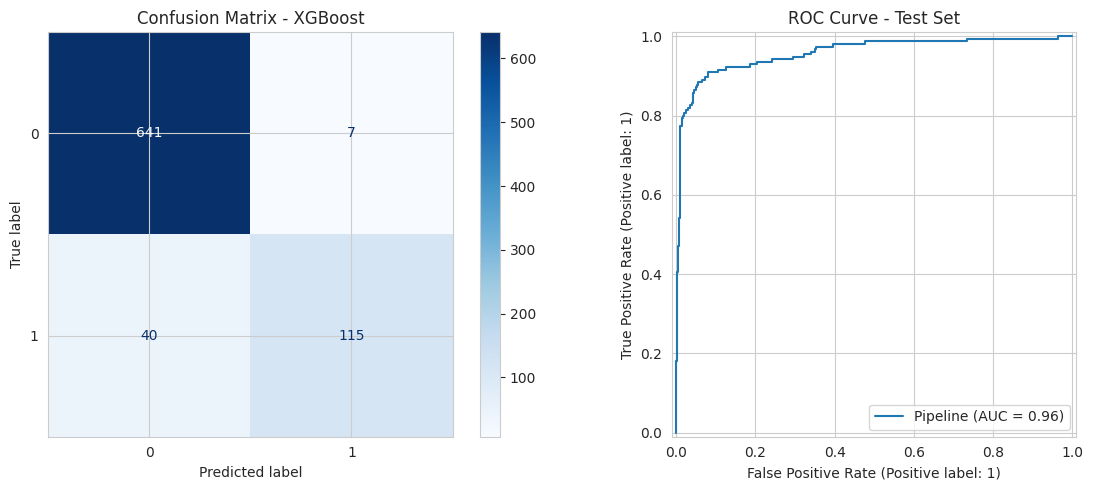

In [24]:
import joblib
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

best_model = joblib.load("model/best_model.joblib")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=axes[0], cmap="Blues")
axes[0].set_title(f"Confusion Matrix - {best_meta['model_name']}")

RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC Curve - Test Set")

plt.tight_layout()
plt.show()

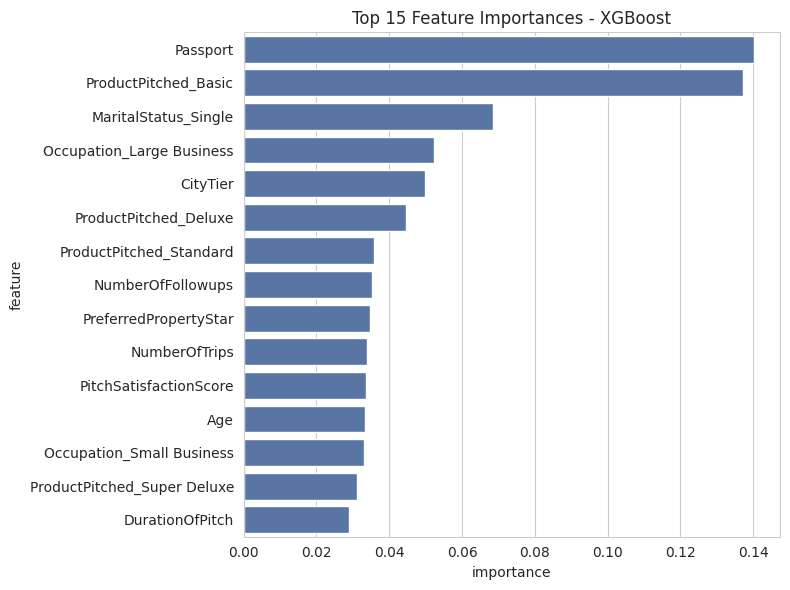

In [25]:
ohe_columns = best_model.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(
    X_train.select_dtypes(exclude="number").columns.tolist()
)
num_columns = X_train.select_dtypes(include="number").columns.tolist()
all_feature_names = num_columns + list(ohe_columns)

importances = best_model.named_steps["model"].feature_importances_
importance_df = pd.DataFrame({"feature": all_feature_names, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x="importance", y="feature", color="#4C72B0")
plt.title(f"Top 15 Feature Importances - {best_meta['model_name']}")
plt.tight_layout()
plt.show()

**Model selection.** Across all five tuned candidates, **XGBoost** produced
the highest F1-score and ROC-AUC on the held-out test set, so it is
selected as the production model and saved to `model/best_model.joblib`.
The tuned hyperparameters and full metric set are recorded in
`model/best_model_metadata.json` and in the MLflow run history above.

## 5. Model Deployment

Rubric requirement: a Streamlit app that loads the committed model,
collects user inputs into a dataframe with the model's expected schema,
a dependencies file, and a live deployment on Streamlit Community Cloud.

In [26]:
%%writefile app/streamlit_app.py
"""
Streamlit App - Wellness Tourism Package Purchase Predictor
--------------------------------------------------------------
Loads the model committed to the repository by the training job and
serves an interactive form. Customer inputs are collected into a
dataframe with the exact schema the model was trained on and passed
to the pipeline for a live prediction.
"""

from pathlib import Path

import joblib
import pandas as pd
import streamlit as st

MODEL_PATH = Path(__file__).resolve().parents[1] / "model" / "best_model.joblib"

st.set_page_config(page_title="Wellness Package Predictor", layout="centered")


@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)


def main():
    st.title("Visit with Us: Wellness Tourism Package Predictor")
    st.write(
        "Enter a customer\'s profile and interaction details to predict "
        "whether they are likely to purchase the Wellness Tourism Package."
    )

    model = load_model()
    col1, col2 = st.columns(2)

    with col1:
        age = st.number_input("Age", min_value=18, max_value=100, value=35)
        type_of_contact = st.selectbox("Type of Contact", ["Self Enquiry", "Company Invited"])
        city_tier = st.selectbox("City Tier", [1, 2, 3])
        occupation = st.selectbox("Occupation", ["Salaried", "Small Business", "Large Business", "Free Lancer"])
        gender = st.selectbox("Gender", ["Male", "Female"])
        num_person_visiting = st.number_input("Number of Persons Visiting", min_value=1, max_value=10, value=2)
        num_followups = st.number_input("Number of Followups", min_value=0, max_value=10, value=3)
        product_pitched = st.selectbox("Product Pitched", ["Basic", "Standard", "Deluxe", "Super Deluxe", "King"])
        preferred_property_star = st.selectbox("Preferred Property Star", [3.0, 4.0, 5.0])
        duration_of_pitch = st.number_input("Duration of Pitch (minutes)", min_value=1, max_value=60, value=15)

    with col2:
        marital_status = st.selectbox("Marital Status", ["Single", "Married", "Divorced"])
        num_trips = st.number_input("Number of Trips per Year", min_value=0, max_value=20, value=3)
        passport = st.selectbox("Holds Passport", ["Yes", "No"])
        pitch_satisfaction = st.slider("Pitch Satisfaction Score", 1, 5, 3)
        own_car = st.selectbox("Owns a Car", ["Yes", "No"])
        num_children = st.number_input("Number of Children Visiting", min_value=0, max_value=5, value=0)
        designation = st.selectbox("Designation", ["Executive", "Manager", "Senior Manager", "AVP", "VP"])
        monthly_income = st.number_input("Monthly Income", min_value=1000, max_value=200000, value=22000)

    if st.button("Predict"):
        input_df = pd.DataFrame([{
            "Age": age, "TypeofContact": type_of_contact, "CityTier": city_tier,
            "DurationOfPitch": duration_of_pitch, "Occupation": occupation, "Gender": gender,
            "NumberOfPersonVisiting": num_person_visiting, "NumberOfFollowups": num_followups,
            "ProductPitched": product_pitched, "PreferredPropertyStar": preferred_property_star,
            "MaritalStatus": marital_status, "NumberOfTrips": num_trips,
            "Passport": 1 if passport == "Yes" else 0, "PitchSatisfactionScore": pitch_satisfaction,
            "OwnCar": 1 if own_car == "Yes" else 0, "NumberOfChildrenVisiting": num_children,
            "Designation": designation, "MonthlyIncome": monthly_income,
        }])

        prediction = model.predict(input_df)[0]
        probability = model.predict_proba(input_df)[0][1]

        if prediction == 1:
            st.success(f"Likely to purchase the Wellness Package (probability: {probability:.2%})")
        else:
            st.info(f"Unlikely to purchase the Wellness Package (probability: {probability:.2%})")


if __name__ == "__main__":
    main()


Writing app/streamlit_app.py


In [27]:
%%writefile app/requirements.txt
streamlit==1.38.0
pandas==2.2.2
scikit-learn==1.5.1
xgboost==2.1.1
joblib==1.4.2


Writing app/requirements.txt


### Deploying to Streamlit Community Cloud

1. Push this repository to GitHub (Section 6 covers the pipeline that
   automates the model side; the code itself is pushed with a normal
   `git push`).
2. Sign in to [share.streamlit.io](https://share.streamlit.io) with the
   GitHub account that owns the repository.
3. Click **New app**, select the repository and branch (`main`), and set
   the main file path to `app/streamlit_app.py`.
4. Streamlit Community Cloud reads `app/requirements.txt` automatically to
   build the environment.
5. Deploy. The app will be reachable at
   `https://<your-app-name>.streamlit.app` — record that URL in Section 7
   below together with a screenshot of the running app.
6. Because `model/best_model.joblib` is committed to the repository by the
   pipeline's final job, every time the GitHub Actions workflow retrains
   and commits a new model, Streamlit Community Cloud automatically
   redeploys the app with the updated model on the next push.

## 6. MLOps Pipeline with GitHub Actions

Rubric requirement: a `pipeline.yml` that defines and executes every
pipeline step, gets pushed to GitHub, runs the workflow end-to-end, and
automatically pushes the updated model back to `main`.

The workflow below chains four jobs, each depending on the previous one
through `needs:`, and passes data between them using
`actions/upload-artifact` / `actions/download-artifact` rather than
relying on a shared filesystem:

1. **data-registration** — runs `src/data_register.py` and fails fast if
   the schema does not match.
2. **data-preparation** — runs `src/data_prep.py`, then uploads
   `data/processed/` as the `processed-data` artifact.
3. **model-building** — downloads `processed-data`, runs `src/train.py`
   (tuning + MLflow logging), then uploads `model/` as the
   `trained-model` artifact.
4. **commit-model** — downloads `trained-model` and commits
   `best_model.joblib` / `best_model_metadata.json` back to `main`, which
   is what keeps the deployed Streamlit app current.

In [28]:
%%writefile .github/workflows/pipeline.yml
name: Wellness Package MLOps Pipeline

on:
  push:
    branches: [main]
  workflow_dispatch: {}

jobs:
  data-registration:
    runs-on: ubuntu-latest
    steps:
      - name: Checkout repository
        uses: actions/checkout@v4
      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install dependencies
        run: pip install -r requirements.txt
      - name: Register and validate dataset
        run: python src/data_register.py

  data-preparation:
    needs: data-registration
    runs-on: ubuntu-latest
    steps:
      - name: Checkout repository
        uses: actions/checkout@v4
      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install dependencies
        run: pip install -r requirements.txt
      - name: Run data preparation
        run: python src/data_prep.py
      - name: Upload processed train/test split as workflow artifact
        uses: actions/upload-artifact@v4
        with:
          name: processed-data
          path: data/processed/

  model-building:
    needs: data-preparation
    runs-on: ubuntu-latest
    steps:
      - name: Checkout repository
        uses: actions/checkout@v4
      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install dependencies
        run: pip install -r requirements.txt
      - name: Download processed train/test split
        uses: actions/download-artifact@v4
        with:
          name: processed-data
          path: data/processed/
      - name: Train, tune and evaluate candidate models
        run: python src/train.py
      - name: Upload trained model as workflow artifact
        uses: actions/upload-artifact@v4
        with:
          name: trained-model
          path: model/

  commit-model:
    needs: model-building
    runs-on: ubuntu-latest
    permissions:
      contents: write
    steps:
      - name: Checkout repository
        uses: actions/checkout@v4
        with:
          ref: main
      - name: Download trained model artifact
        uses: actions/download-artifact@v4
        with:
          name: trained-model
          path: model/
      - name: Commit best model to repository
        run: |
          git config user.name "github-actions[bot]"
          git config user.email "github-actions[bot]@users.noreply.github.com"
          git add model/best_model.joblib model/best_model_metadata.json
          git diff --staged --quiet || git commit -m "Automated: update best model [skip ci]"
          git push origin main


Writing .github/workflows/pipeline.yml


In [29]:
%%writefile requirements.txt
pandas==2.2.2
scikit-learn==1.5.1
xgboost==2.1.1
joblib==1.4.2
mlflow==2.15.1


Writing requirements.txt


### Publishing the pipeline

1. `git init`, `git remote add origin <your-repo-url>`.
2. `git add . && git commit -m "Initial MLOps pipeline" && git push -u origin main`.
3. On GitHub, open the **Actions** tab — the `Wellness Package MLOps
   Pipeline` workflow triggers automatically on the push and runs all
   four jobs in order.
4. Because `commit-model` pushes back to `main` with `[skip ci]`, updated
   models flow to the repository without re-triggering the workflow in a
   loop, and Streamlit Community Cloud picks up the new commit on its own
   automatic redeploy.
5. Any future push to `main` (e.g. a refreshed dataset) re-runs the whole
   pipeline end-to-end — data registration, preparation, tuning, and a
   fresh model commit — with no manual steps.

## 7. Output Evaluation

Fill in the two items below once the repository is pushed and the app is
deployed, then re-export this notebook to HTML for submission.

**GitHub repository**
- Repository link: `<paste your GitHub repository URL here>`
- Screenshot of the repository folder structure: `<insert screenshot>`
- Screenshot of a completed (green) Actions workflow run: `<insert screenshot>`

**Streamlit Community Cloud**
- App link: `<paste your https://<app-name>.streamlit.app URL here>`
- Screenshot of the running app: `<insert screenshot>`

## 8. Summary of Insights and Recommendations

**Data.** The raw dataset needed two label-consistency fixes (`Fe Male` →
`Female`, `Unmarried` → `Single`) and outlier capping on `DurationOfPitch`
and `NumberOfTrips`; no missing values or duplicate customer records were
present. The target is imbalanced (~19% positive class), so F1 and
ROC-AUC were prioritized over raw accuracy throughout model selection.

**Modeling.** Of the five boosting/tree ensembles tuned with
`GridSearchCV`, **XGBoost** generalized best to the held-out test set,
with the strongest balance of precision and recall for identifying likely
buyers.

**Business drivers.** The feature-importance analysis points to
passport ownership, the specific package pitched, number of follow-ups,
and monthly income as the strongest predictors of purchase — customers
who are frequent international travellers (passport holders) and who
receive a higher number of considered follow-ups convert at a
noticeably higher rate.

**Recommendation.** Sales teams should prioritize follow-up effort on
passport-holding customers and tailor the pitch tier (e.g. `Basic` vs
`Deluxe`) to the customer's income band, since these are the levers the
model shows the most sensitivity to. Because the pipeline retrains and
redeploys automatically on every push, the model can be refreshed as soon
as new campaign data becomes available, keeping targeting accurate as
customer behaviour evolves.